In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import other libraries when needed 

In [2]:
# Load raw data
df = pd.read_parquet("..\dataDumper.parquet")

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\natha\AppData\Local\Temp\ipykernel_20028\2930624869.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_parquet("..\dataDumper.parquet")


In [3]:
df.head(3)

,Time_utc,VehicleName,VehicleType,Pressure_Pa_1,Pressure_Pa_2,Pressure_Pa_3,Pressure_Pa_4,Pressure_Pa_5,Pressure_Pa_6,Temperature_K_1,...,Altitude_m,Speed_mps,epsilonX,epsilonY,epsilonZ,epsilonSpeed,AtmosphericPressure_Pa,dt_s,dd_m,RatioPayload
0,2023-01-01 00:00:00.328,C-132,Dumper,993010.933333,1.003995e+06,856000.0,798005.466667,819994.533333,864994.533333,346.15,...,4581.000000,9.003,6.207,6.312,23.000000,0.0,59002.557667,4.912,41.480140,0.0
1,2023-01-01 00:00:05.338,C-132,Dumper,993177.933329,1.003911e+06,856000.0,798088.966665,819911.033335,864911.033335,346.15,...,4577.600098,9.003,6.393,6.797,27.600000,0.0,59028.296172,5.010,45.952211,0.0
2,2023-01-01 00:00:10.331,C-132,Dumper,993344.366669,1.003828e+06,856000.0,798172.183334,819827.816666,864827.816666,346.15,...,4573.000000,9.723,6.721,7.631,32.200001,0.0,59064.789917,4.993,47.007842,0.0


In [4]:
df.columns

Index(['Time_utc', 'VehicleName', 'VehicleType', 'Pressure_Pa_1',
       'Pressure_Pa_2', 'Pressure_Pa_3', 'Pressure_Pa_4', 'Pressure_Pa_5',
       'Pressure_Pa_6', 'Temperature_K_1', 'Temperature_K_2',
       'Temperature_K_3', 'Temperature_K_4', 'Temperature_K_5',
       'Temperature_K_6', 'ColdPressure_Pa_1', 'ColdPressure_Pa_2',
       'ColdPressure_Pa_3', 'ColdPressure_Pa_4', 'ColdPressure_Pa_5',
       'ColdPressure_Pa_6', 'Latitude_dd', 'Longitude_dd', 'Altitude_m',
       'Speed_mps', 'epsilonX', 'epsilonY', 'epsilonZ', 'epsilonSpeed',
       'AtmosphericPressure_Pa', 'dt_s', 'dd_m', 'RatioPayload'],
      dtype='object')

In [5]:
df[['phaseNb']] = df[['RatioPayload']].diff().abs().cumsum()

In [6]:
dd_m_df = df[[
    "Time_utc", "VehicleName", "VehicleType", "AtmosphericPressure_Pa", "Latitude_dd", "Longitude_dd",
    "Altitude_m","Speed_mps", "epsilonX", "epsilonY", "epsilonZ", "epsilonSpeed","AtmosphericPressure_Pa", "dt_s", "dd_m", "RatioPayload",
    "phaseNb"
    ]]

In [7]:
mask_dd_m_na_values = dd_m_df[["AtmosphericPressure_Pa"]].isna()

In [8]:
dd_m_na_values_df = dd_m_df[mask_dd_m_na_values.any(axis = 1)]
dd_m_na_values_index = dd_m_na_values_df.index

In [9]:
dd_m_na_values_df["Time_utc"]

13366     2023-01-01 19:25:07.544
34420     2023-01-03 01:23:16.486
35198     2023-01-03 02:44:42.324
35199     2023-01-03 02:44:47.308
38347     2023-01-03 11:17:37.285
                   ...           
191231    2023-01-14 09:21:39.313
198157    2023-01-14 19:22:17.385
198158    2023-01-14 19:22:22.380
198159    2023-01-14 19:22:27.390
198160    2023-01-14 19:22:32.350
Name: Time_utc, Length: 957, dtype: object

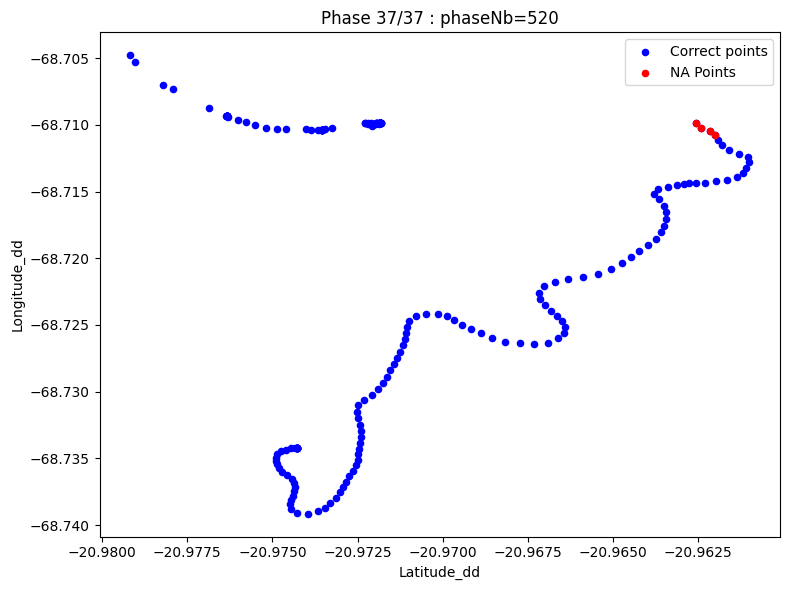

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

phases = dd_m_na_values_df["phaseNb"].unique().tolist()
print(f"Number of phases with missing values : {len(phases)}")

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    dd_m_df_sample = dd_m_df[dd_m_df["phaseNb"] == phase_nb]
    tire1_na_values_sample_df = dd_m_na_values_df[dd_m_na_values_df["phaseNb"] == phase_nb]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(dd_m_df_sample['Latitude_dd'], dd_m_df_sample['Longitude_dd'], s=20, c="blue", label="Correct points")
    ax.scatter(tire1_na_values_sample_df['Latitude_dd'], tire1_na_values_sample_df['Longitude_dd'], s=20, c="red", label="NA Points")
    ax.set_title(f"Phase {i+1}/{len(phases)} : phaseNb={int(phase_nb)}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if i < len(phases)-1:
        input("Press enter for the next phase...")

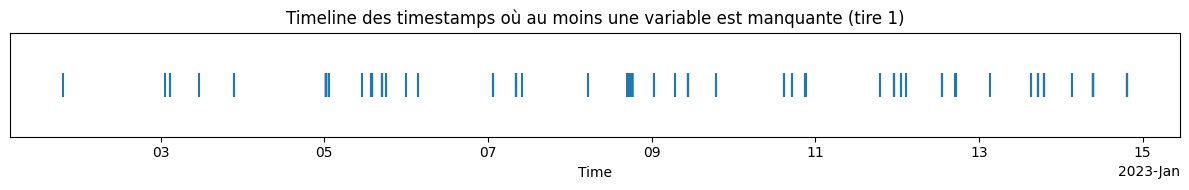

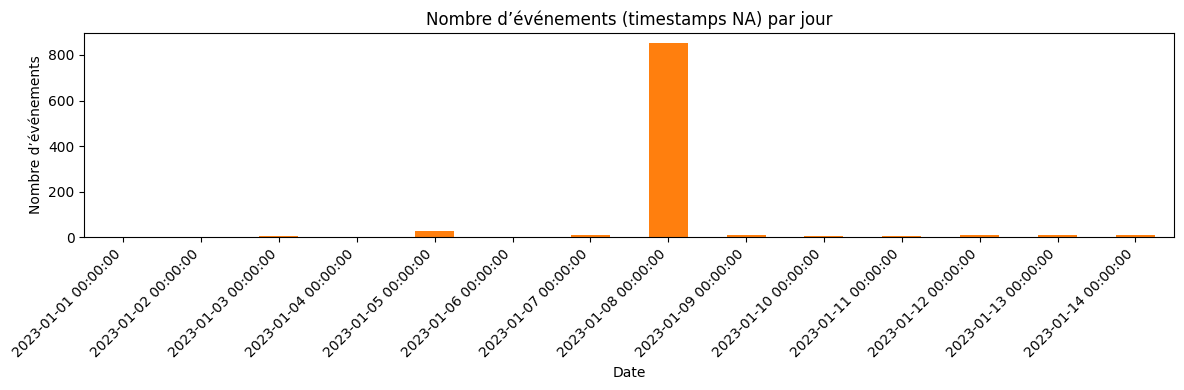

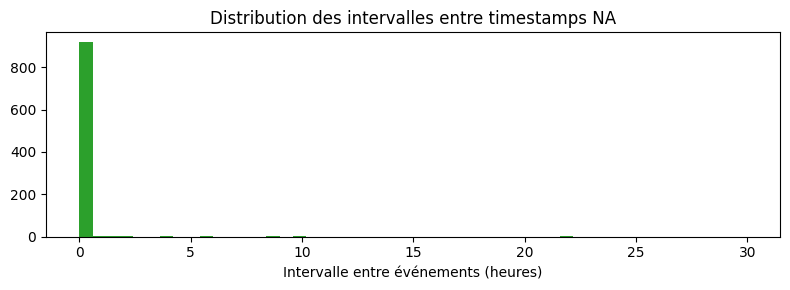

In [11]:
# Visualiser les timestamps des enregistrements avec valeurs manquantes
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Extraire la colonne brute
ts_raw = dd_m_na_values_df["Time_utc"]

# Tenter conversion en datetime de manière robuste
ts = pd.to_datetime(ts_raw, errors='coerce')
# Si tout échoue et que c'est numérique, réessayer en supposant des secondes UNIX
if ts.isna().all() and pd.api.types.is_numeric_dtype(ts_raw):
    ts = pd.to_datetime(ts_raw, unit='s', errors='coerce')

# Supprimer les NaT
ts = ts.dropna().sort_values()

if ts.empty:
    print("Aucun timestamp valide trouvé dans 'Time_utc' (après conversion).")
else:
    # Figure 1 : timeline (markers verticaux)
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.scatter(ts, [1] * len(ts), marker='|', s=300, color='tab:blue')
    ax.set_yticks([])
    ax.set_title('Timeline des timestamps où au moins une variable est manquante (tire 1)')
    ax.set_xlabel('Time')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
    plt.tight_layout()
    plt.show()

    # Figure 2 : nombre d'événements par jour
    counts = ts.dt.floor('D').value_counts().sort_index()
    # convertir en Series avec fréquence journalière pour afficher les jours sans événements
    counts_daily = counts.asfreq('D', fill_value=0) if not counts.empty else counts

    fig, ax = plt.subplots(figsize=(12, 4))
    counts_daily.plot(ax=ax, kind='bar', color='tab:orange')
    ax.set_title('Nombre d’événements (timestamps NA) par jour')
    ax.set_xlabel('Date')
    ax.set_ylabel('Nombre d’événements')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Optionnel : histogramme des intervalles entre événements
    inter = ts.diff().dropna().dt.total_seconds()
    if not inter.empty:
        fig, ax = plt.subplots(figsize=(8,3))
        ax.hist(inter / 3600.0, bins=50, color='tab:green')
        ax.set_xlabel('Intervalle entre événements (heures)')
        ax.set_title("Distribution des intervalles entre timestamps NA")
        plt.tight_layout()
        plt.show()